/var/folders/vd/d1shw27j5yq35j58_l9vjl280000gn/T/ipykernel_23782/69694016.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


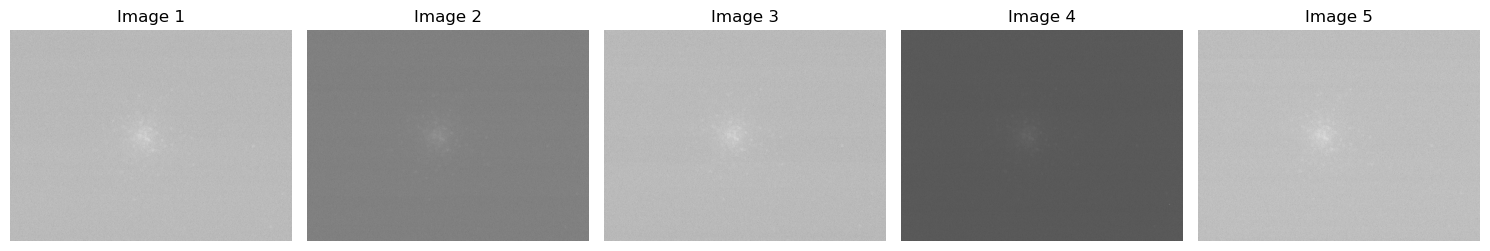

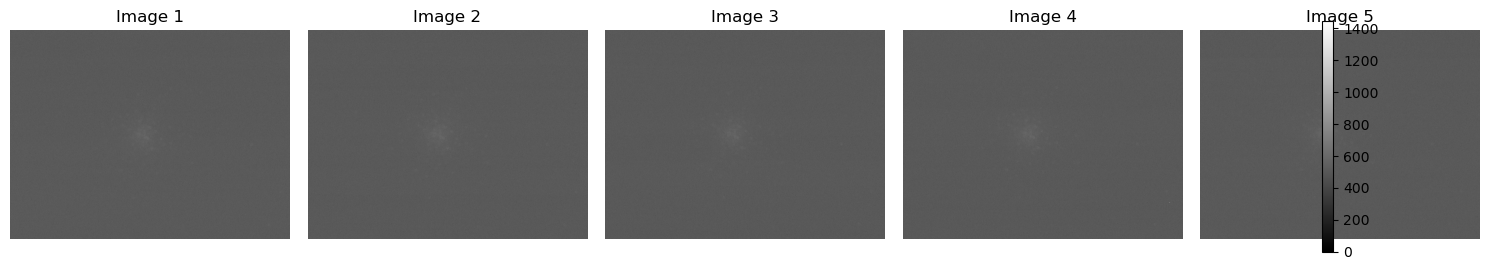

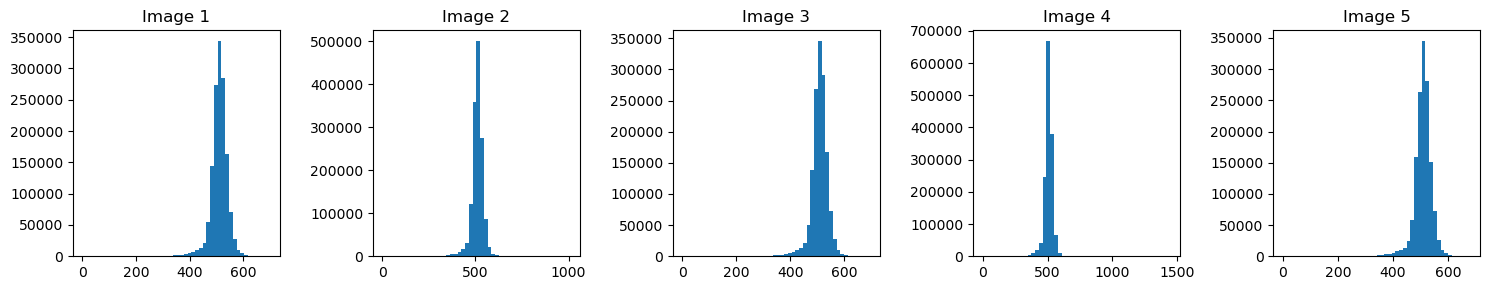

Image 1: mean = 510.47, median = 512.00
Image 2: mean = 509.75, median = 511.00
Image 3: mean = 508.05, median = 510.00
Image 4: mean = 507.91, median = 509.00
Image 5: mean = 508.79, median = 510.00
The X-axis represents pixel intensity values (brightness) and the Y-axis represents the # of pixels (freq.)
Bins=50 divides the range of pixel values into 50 intervals (bins)
Most values are typically clustered around the background level, appearing as a large peak in the histogram
The bulk of the data is usually narrowly distributed around the background
Median = backgrouns level and Mean = slightly higher because bright stars pull it up


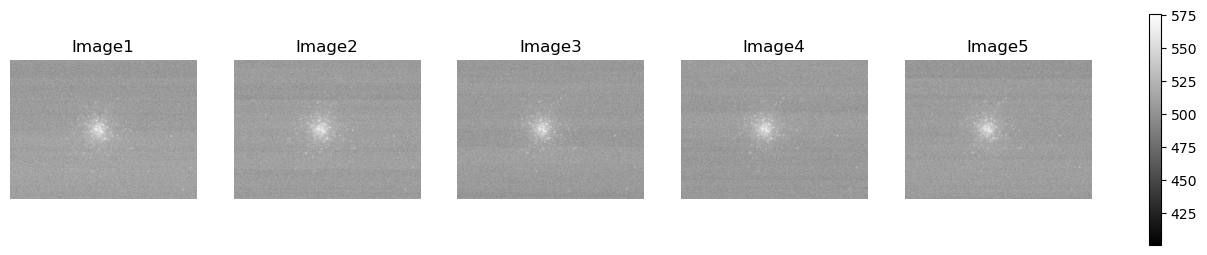

In [16]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

#3.1
data_list = []
header_list = []

for i in range(1, 6):
    filename = f"M13_{i:04d}.fits"
    with fits.open(filename) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        header_list.append(header)
        data_list.append(data)
#3.2
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range (5):
    axes[i].imshow(data_list[i], origin="lower", cmap="gray")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show

#3.3
vmin = min(data.min() for data in data_list)
vmax = max(data.max() for data in data_list)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    im = axes[i].imshow(data_list[i], origin="lower", cmap="gray",
                        vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02)
plt.tight_layout()
plt.show()

#3.4
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
means = []
medians = []
for i in range(5):
    data = data_list[i]
    axes[i].hist(data.ravel(), bins=50)
    axes[i].set_title(f"Image {i+1}")
    means.append(np.mean(data))
    medians.append(np.median(data))
plt.tight_layout()
plt.show()
for i in range(5):
    print(f"Image {i+1}: mean = {means[i]:.2f}, median = {medians[i]:.2f}")

#a)
print("The X-axis represents pixel intensity values (brightness) and the Y-axis represents the # of pixels (freq.)")

#b)
print("Bins=50 divides the range of pixel values into 50 intervals (bins)")

#c)
print("Most values are typically clustered around the background level, appearing as a large peak in the histogram")

#d)
print("The bulk of the data is usually narrowly distributed around the background")

#e)
print("Median = backgrouns level and Mean = slightly higher because bright stars pull it up")

combined_image = np.mean(data_list, axis=0)
fits.writeto("combined.fits", combined_image, overwrite=True)

#3.5
all_pixels = np.concatenate([data.ravel() for data in data_list])


vmin = np.percentile(all_pixels, 1)
vmax = np.percentile(all_pixels, 99)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    im = axes[i].imshow(data_list[i], origin="lower", cmap="gray",
                        vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image{i+1}")
    axes[i].axis("off")
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02)
plt.show()